# Fig. 4, Extended Fig. 4: Behavioral timescale sequences

### Table of Contents

[Load multiDayData, where cells have already been classified by remapping type](#Load-pre-saved-multiDayData)  \
[Plot sorted cell sequences](#Sequences)  \
[Plot rainbow histograms of sequence shapes, plus quantification](#Start-here-for-Fig-4j-onward)


In [1]:
%matplotlib inline
# inline, widget

import math
import sys
import os
import glob
import pickle
import dill
import numpy as np
import scipy as sp
import pandas as pd
import warnings
from tqdm import tqdm
import itertools
import copy
import astropy
from astropy import stats
import phase_precession.core as ppcore
from datetime import datetime

from matplotlib import pyplot as plt, axes as axes
from matplotlib import gridspec, cm
import statsmodels.formula.api as smf
import seaborn as sns
sns.set_style("white")

from reward_relative import behavior as behav
from reward_relative import preprocessing as pp
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import xcorr as xc
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import multiDayROIAlign as roiAlign
from reward_relative import circ
from reward_relative import rewardAnalysis as ra
from reward_relative import regression
    
import TwoPUtils

import sklearn
from sklearn.impute import KNNImputer


%load_ext autoreload
%autoreload 2

save_figures = False

In [2]:
from reward_relative.path_dict_firebird import path_dictionary as path_dict

In [3]:
path_dict

{'preprocessed_root': '/data/2P',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2P/VR_Data',
 'git_repo_root': '/home/mari/local_repos/2p_repos',
 'TwoPUtils': '/home/mari/local_repos/2p_repos/TwoPUtils',
 'home': '/home/mari',
 'fig_dir': '/data/2P/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2P/fig_scratch/Apr2025


## Load pre-saved multiDayData

To make multiDayData, run `make_multiDayData_class.ipynb`

In [5]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment, exp_days, year='combined')
ts_key = 'dff'  # used to find place field peaks
smooth = False  # whether to smooth for finding place cell peaks
sigma = 1
exclude_int = True  # exclude putative interneurons
int_thresh = 0.5

place_cell_logical = 'or'

reward_dist_inclusive = 50
reward_dist_exclusive = 50

use_speed_thr = True

dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multiDayData', pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path, "rb"))

include_ans = multiDayData[exp_days[-1]
                           ].circ_rel_stats_across_an['include_ans']

/data/2P/multiDayData/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


# Sequences

## Assessing sequences relative to reward

[Back to table of contents](#Table-of-Contents)


### Plot sorted cell sequences, compute permutations & circular-circular correlations

In [ ]:
# celltype options: 'rr', 'track', 'appear', 'disappear', 'nonreward_remap'
celltype = 'rr' # if 'appear', set 'sort_by_set1' to True; otherwise False

include_ans = multiDayData[exp_days[-1]
                           ].circ_rel_stats_across_an['include_ans'].tolist()
seq, seq_df, fig, fig_q = placeCellPlot.plot_sequences(multiDayData,
                                               celltype=celltype,
                                               daylist=exp_days,
                                               smooth=False,
                                               use_peaks=True,
                                               use_circ_mean=False,
                                               plot=True,
                                               save_figures=False,
                                               fig_dir=fig_dir,
                                               sort_by_set1=False,
                                               last_10_trials=False,
                                               vmax=5,
                                               vbin=1,
                                               vmin=0,
                                               include_ans=include_ans,
                                               p_thr=0.05,
                                           )

In [21]:
seq_df_src = seq_df[['mouse','day','switch','cc_rho','cc_rho_perm95','p_from_shuf']]
seq_df_src['switch'] = seq_df_src['switch']+1
seq_df_src

<ipython-input-21-2ec45f2f2404>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seq_df_src['switch'] = seq_df_src['switch']+1


,mouse,day,switch,cc_rho,cc_rho_perm95,p_from_shuf
0,GCAMP3,3,1,0.152707,0.210272,0.223776
1,GCAMP4,3,1,0.490590,0.204742,0.000999
2,GCAMP7,3,1,0.292823,0.240830,0.039960
3,GCAMP11,3,1,0.089065,0.552524,0.800200
4,GCAMP12,3,1,-0.021814,0.196498,0.852148
...,...,...,...,...,...,...
72,GCAMP14,14,7,0.190424,0.157618,0.059940
73,GCAMP15,14,7,-0.135736,0.176444,0.217782
74,GCAMP17,14,7,-0.146037,0.430521,0.624376
75,GCAMP18,14,7,0.161017,0.126410,0.055944


In [22]:
# ut.write_source_csv(seq_df_src, "4i")

writing /data/2P/source_data/Fig4i.csv


# Start here for Fig 4j onward

### Come back here when you want to change "cell type"

In [29]:
## First get sequence info again without plotting

celltype = 'rr' ## <--- Set celltype here for the next few sections

# celltype options: 'rr', 'track', 'appear', 'disappear', 'nonreward_remap'

include_ans = multiDayData[exp_days[0]].circ_rel_stats_across_an['include_ans'].tolist()
seq, _, _, _ = placeCellPlot.plot_sequences(multiDayData,
                                 celltype=celltype,
                                 daylist=exp_days,
                                 smooth=False,
                                 use_peaks=True,
                                 use_circ_mean=False,
                                 plot=False,
                                 save_figures=False,
                                 sort_by_set1=False,
                                 last_10_trials=False,
                                 vmax=5,
                                 vbin=1,
                                 include_ans=include_ans,
                                 p_thr=0.05,
                         )

### Find shape of sequence

In [30]:
# Shape of sequences for each animal, before vs after
print(celltype) # NOTE THIS IS SET ABOVE

anchor_to_reward = True # set to True for reward-relative, False for track-relative
if anchor_to_reward:
    anchor_tag = 'rranchor'
else:
    anchor_tag = 'linanchor'

bin_size = (2*np.pi)/45
bin_edges = np.arange(-np.pi, np.pi+bin_size, bin_size)

bin_centers = bin_edges[:-1]+bin_size/2

lick_bin_size = (2*np.pi)/45  # np.pi/24
lick_bin_edges = np.arange(-np.pi, np.pi+lick_bin_size, lick_bin_size)
lick_bin_centers = lick_bin_edges[:-1]+lick_bin_size/2

# Set some plotting definitions
palette = 'tab10'
seaborn_palette = sns.color_palette(
    palette, len(include_ans))  # , as_cmap=True)
rgb_tuples = [sns.color_palette(seaborn_palette)[i]
              for i in range(len(seaborn_palette))]
cmap = np.asarray(rgb_tuples)


alphas = np.linspace(0.2, 1, len(exp_days))

mean_seq_pos = {}
seq_pos0 = {}
seq_pos1 = {}

cols = ['an', 'day', 'switch', 'switch_dir', 'seqvar0', 'seqvar1',
        'lickvar0', 'lickvar1',
        'lickratio0', 'lickratio1',
        'seqmean0', 'seqmean1']

seq_shape_df = pd.DataFrame(data=np.zeros(
    (len(exp_days)*len(include_ans), len(cols))), columns=cols)
seq_shape_df['an'] = np.tile(include_ans, (len(exp_days), 1)).ravel()
seq_shape_df['day'] = np.repeat(exp_days, len(include_ans))
seq_shape_df['switch'] = np.repeat(np.arange(len(exp_days)), len(include_ans))

for d_i, d in enumerate(seq.keys()):

    mean_seq_pos[d] = {}
    seq_pos0[d] = {}
    seq_pos1[d] = {}

    for an_i, an in enumerate(include_ans):
        n_cells = np.sum(
            [len(multiDayData[d].overall_place_cell_masks[an]) for an in include_ans])
        _circpos = multiDayData[d].circ_trial_matrix[an][-1]
        if anchor_to_reward:
            seq_pos0[d][an] = seq[d][an]['dist_to_reward0']
            seq_pos1[d][an] = seq[d][an]['dist_to_reward1']
            rpos0 = 0
            rpos1 = 0

            mean_seq_pos[d][an] = seq_pos1[d][an]
        else:
            seq_pos0[d][an] = seq[d][an]['seq0']
            seq_pos1[d][an] = seq[d][an]['seq1']
            rpos0 = spatial.pos_cm_to_rad(
                multiDayData[d].rzone_pos[an]['set 0'][0], 450, 0)
            rpos1 = spatial.pos_cm_to_rad(
                multiDayData[d].rzone_pos[an]['set 1'][0], 450, 0)
            mean_seq_pos[d][an] = seq_pos1[d][an]

        if celltype == 'appear' or celltype == 'nonreward_remap':
            mean_seq_pos[d][an] = seq_pos1[d][an]
        if celltype == 'disappear':
            mean_seq_pos[d][an] = seq_pos0[d][an]

        if np.all(np.isnan(mean_seq_pos[d][an])):
            # set to -10000 because this will never be in the histogram bins
            mean_seq_pos[d][an] = [-10000]

        if np.any(~np.isnan(seq_pos0[d][an])):

#             hist_0, _ = np.histogram(seq_pos0[d][an], bins=bin_edges)
#             hist_norm_to_seq_0 = (hist_0 / len(seq_pos0[d][an]))
#             hist_norm_to_all_0 = hist_0 / n_cells

#             hist_1, _ = np.histogram(seq_pos1[d][an], bins=bin_edges)
#             hist_norm_to_seq_1 = (hist_1 / len(seq_pos1[d][an]))
#             hist_norm_to_all_1 = hist_1 / n_cells


#             seqvar0[an_i, d_i] = astropy.stats.circstats.circvar(
#                 seq_pos0[d][an])
#             seqvar1[an_i, d_i] = astropy.stats.circstats.circvar(
#                 seq_pos1[d][an])

            this_df_idx = ((seq_shape_df['an'] == an)
                           & (seq_shape_df['day'] == d))

            seq_shape_df.loc[this_df_idx, 'seqvar0'] = astropy.stats.circstats.circvar(
                seq_pos0[d][an])
            seq_shape_df.loc[this_df_idx, 'seqvar1'] = astropy.stats.circstats.circvar(
                seq_pos1[d][an])
            seq_shape_df.loc[this_df_idx, 'seqmean0'] = astropy.stats.circstats.circmean(
                seq_pos0[d][an])
            seq_shape_df.loc[this_df_idx, 'seqmean1'] = astropy.stats.circstats.circmean(
                seq_pos1[d][an])

            if multiDayData[d].rzone_pos[an]['set 1'][0] > multiDayData[d].rzone_pos[an]['set 0'][0]:
                seq_shape_df.loc[this_df_idx, 'switch_dir'] = 'forward'
            elif multiDayData[d].rzone_pos[an]['set 1'][0] < multiDayData[d].rzone_pos[an]['set 0'][0]:
                seq_shape_df.loc[this_df_idx, 'switch_dir'] = 'backward'
            else:
                switch_dir = 'none'

            # For now
            # mean circular licking variance across "before" trials
            tmp_lickvar = np.zeros(
                (multiDayData[d].circ_licks[an]['set 0'].shape[0],))*np.nan
            for ti in range(multiDayData[d].circ_licks[an]['set 0'].shape[0]):
                tmp_lickvar[ti] = astropy.stats.circstats.circvar(lick_bin_centers[
                    multiDayData[d].circ_licks[an]['set 0'][ti, :] > 0])
            tmp_lickvar = tmp_lickvar[~np.isnan(tmp_lickvar)]

            seq_shape_df.loc[this_df_idx, 'lickvar0'] = astropy.stats.circstats.circmean(
                tmp_lickvar)

            seq_shape_df.loc[this_df_idx, 'lickratio0'] = np.nanmean(
                multiDayData[d].in_vs_out_lickratio[an]['set 0'])

            # mean circular licking variance across "after" trials
            tmp_lickvar = np.zeros(
                (multiDayData[d].circ_licks[an]['set 1'].shape[0],))*np.nan
            for ti in range(multiDayData[d].circ_licks[an]['set 1'].shape[0]):

                tmp_lickvar[ti] = astropy.stats.circstats.circvar(lick_bin_centers[
                    multiDayData[d].circ_licks[an]['set 1'][ti, :] > 0])
            tmp_lickvar = tmp_lickvar[~np.isnan(tmp_lickvar)]

            seq_shape_df.loc[this_df_idx, 'lickvar1'] = astropy.stats.circstats.circmean(
                tmp_lickvar)
            
            seq_shape_df.loc[this_df_idx, 'lickratio1'] = np.nanmean(
                multiDayData[d].in_vs_out_lickratio[an]['set 1'])


seq_shape_df['seqmean0_cm'] = spatial.dist_rad_to_cm(
    seq_shape_df['seqmean0'], 450, 0)
seq_shape_df['seqmean1_cm'] = spatial.dist_rad_to_cm(
    seq_shape_df['seqmean1'], 450, 0)
# rho, pval, slope, phi, gof = ppcore.cl_corr(all_lickposstd, all_circvar, -1, 1, return_pval=True)
# ax3.set_title('rho=%.2e, p=%.2e' % (rho,pval))

rr


/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/astropy/stats/circstats.py:31: RuntimeWarning: invalid value encountered in double_scalars
  C = np.sum(weights * np.cos(p * (data - phi)), axis)/np.sum(weights, axis)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/astropy/stats/circstats.py:32: RuntimeWarning: invalid value encountered in double_scalars
  S = np.sum(weights * np.sin(p * (data - phi)), axis)/np.sum(weights, axis)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/astropy/stats/circstats.py:31: RuntimeWarning: invalid value encountered in double_scalars
  C = np.sum(weights * np.cos(p * (data - phi)), axis)/np.sum(weights, axis)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/astropy/stats/circstats.py:32: RuntimeWarning: invalid value encountered in double_scalars
  S = np.sum(weights * np.sin(p * (data - phi)), axis)/np.sum(weights, axis)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/astropy/

## Density of sequences 
(shape of distribution of positions relative to reward or track)

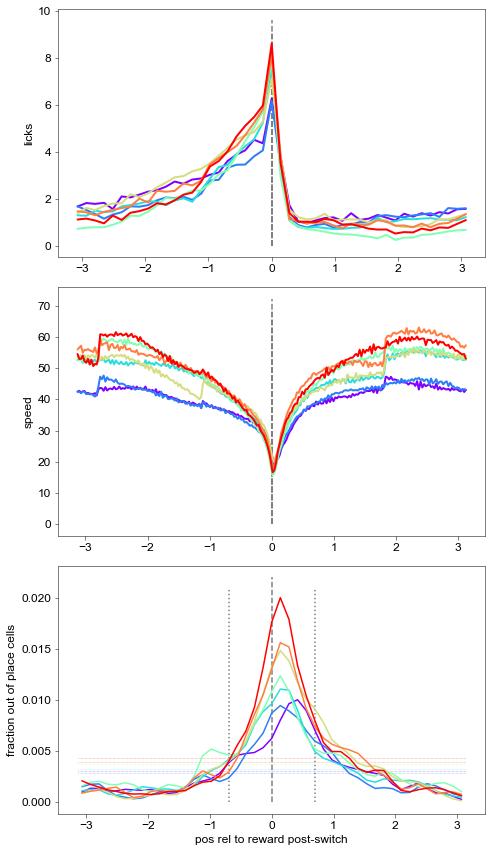

In [31]:
# plotting options
smooth_histogram = True
omit_SEM = True

daylist= exp_days #[3,5,7,8,10,12,14]
colors = cm.rainbow(np.linspace(0,1,len(daylist)))
fig,ax = plt.subplots(3,1,figsize=(7,12))

lick_bin_size = (2*np.pi)/45
lick_bin_edges = np.arange(-np.pi, np.pi+lick_bin_size, lick_bin_size)
lick_bin_centers = lick_bin_edges[:-1]+lick_bin_size/2

collect_licks = {}
collect_speed = {}
collect_seq = {}

norm_to_all_cells = False
norm_to_place_cells = True
norm_to_seq = False


for d_i,d in enumerate(daylist):
    
    # only plot behavior when anchored to reward
    if anchor_to_reward:
        stack_lick = np.vstack([np.nanmean(
            multiDayData[d].circ_licks[an]['set 1'], axis=0,keepdims=True) for an in include_ans]
                              )


        collect_licks[d] = pd.DataFrame(stack_lick, columns=lick_bin_centers)

        mean_lick = np.nanmean(stack_lick, axis=0)
        sem_lick = ut.sem(stack_lick,axis=0)

        ax[0].plot(lick_bin_centers,
                     mean_lick,
                     color = colors[d_i],
                    linewidth=2)

        ax[0].vlines(0,0, ax[0].get_ylim()[-1],linestyle='--',color='grey')
        ax[0].set_ylabel('licks')

        stack_speed = np.vstack([np.nanmean(multiDayData[d].circ_speed[an]['set 1'][0],
                                            axis=0,keepdims=True) for an in include_ans])

        speed_bin_centers = multiDayData[exp_days[0]].circ_speed[include_ans[0]]['set 1'][-1]
        collect_speed[d] = pd.DataFrame(stack_speed, columns=speed_bin_centers)

        mean_speed = np.nanmean(stack_speed,axis=0)  
        sem_speed = ut.sem(stack_speed, axis=0)

        ax[1].plot(speed_bin_centers,
                     mean_speed,
                     color = colors[d_i],
                    linewidth=2)

        ax[1].vlines(0,0, ax[1].get_ylim()[-1],linestyle='--',color='grey')
        ax[1].set_ylabel('speed')

    n_all_cells = np.sum([len(multiDayData[d].overall_place_cell_masks[an]) for an in include_ans]) # n all cells
    n_place_cells = np.sum([np.sum(multiDayData[d].overall_place_cell_masks[an]) for an in include_ans])
    n_seq = [len(mean_seq_pos[d][an]) for an in include_ans]
                                                        

    ## Get means across each animal's sequence histogram
    ## Select normalization method
    
    if norm_to_all_cells:

        yax = 'fraction out of all cells'
        normtag = 'ofAllCells'
        
        hist_mat = np.hstack([np.expand_dims((np.histogram(mean_seq_pos[d][an], 
                                                                  bins=bin_edges
                                                              )[0] / len(
            multiDayData[d].overall_place_cell_masks[an])),
                                       axis=1)                       
                    for an in include_ans])
        
        n_total = n_all_cells
        
    elif norm_to_place_cells: #used for the paper
     
        hist_mat = np.hstack([np.expand_dims((np.histogram(mean_seq_pos[d][an], 
                                                       bins=bin_edges)[0] / np.sum(
            multiDayData[d].overall_place_cell_masks[an])), 
                               axis=1)
                for an in include_ans])
        yax = 'fraction out of place cells'
        normtag = 'ofPlaceCells'
        
        n_total = n_place_cells
        
        # chance = mean fraction of pcs within animal comprised by the sequence, 
        # divided by the number of bins
        seq_of_pcs_list = [len(mean_seq_pos[d][an])/np.sum(multiDayData[d].overall_place_cell_masks[an]) for an in include_ans]
        chance = np.mean(seq_of_pcs_list)/len(bin_centers)
    
    
    if norm_to_seq:
        yax = 'fraction out of seq.'
        normtag = 'ofSeq'
        
        hist_mat = np.hstack([np.expand_dims((np.histogram(mean_seq_pos[d][an], 
                                                                      bins=bin_edges
                                                                  )[0] / len(mean_seq_pos[d][an])),
                                           axis=1)                       
                        for an in include_ans])
        
        chance = 1/len(bin_centers)
        n_total = np.sum([len(mean_seq_pos[d][an]) for an in include_ans])
        
    collect_seq[d] = pd.DataFrame(ut.nansmooth(hist_mat.T, 1, axis=1), columns=bin_centers)
    
    hist_mean = np.nanmean(hist_mat,axis=1)
    hist_sem = ut.sem(hist_mat,axis=1)
    
    ## Plot histograms:
    if smooth_histogram:
        if omit_SEM:
            ax[2].plot(bin_centers, ut.nansmooth(hist_mean,1), color = colors[d_i,:])
        else:
            pt.plot_mean_sem(ax[2], ut.nansmooth(hist_mean,1), ut.nansmooth(hist_sem,1),xvalues=bin_centers,color = colors[d_i,:])
    else:
        if omit_SEM:
            ax[2].plot(bin_centers, hist_mean, color = colors[d_i,:])
        else:
            pt.plot_mean_sem(ax[2], hist_mean, hist_sem,xvalues=bin_centers,color = colors[d_i,:])  
    
    ax[2].hlines(chance, -np.pi, np.pi, linestyle=":", color=colors[d_i,:], alpha=0.8, linewidth=0.5)
    
ax[2].set_ylabel(yax)
ylim = ax[2].get_ylim()[-1]
if anchor_to_reward:
    if celltype=='disappear':
        ax[2].set_xlabel('pos rel to reward pre-switch')
    else:
        ax[2].set_xlabel('pos rel to reward post-switch')
    ax[2].vlines(-multiDayData[d].circ_rel_stats_across_an['rdist_to_rad_exc'],0, ylim,linestyle=':',color='grey')
    ax[2].vlines(multiDayData[d].circ_rel_stats_across_an['rdist_to_rad_exc'],0, ylim,linestyle=':',color='grey')
else:
    if celltype=='disappear':
        ax[2].set_xlabel('pos on track pre-switch')
    else:
        ax[2].set_xlabel('pos on track post-switch')

    # plot reward locs
    ax[2].vlines(spatial.pos_cm_to_rad(80, 450,0),0, 0.005, color='blue', linestyle='--', linewidth=0.75)
    ax[2].vlines(spatial.pos_cm_to_rad(200, 450,0),0, 0.005, color='purple', linestyle='--', linewidth=0.75)
    ax[2].vlines(spatial.pos_cm_to_rad(320, 450,0),0, 0.005, color='red', linestyle='--', linewidth=0.75)
ax[2].vlines(0,0, ax[2].get_ylim()[-1],linestyle='--',color='grey')    


save_figures = False
if save_figures:
    if anchor_to_reward:
        anchor_tag = 'rranchor'
    else:
        anchor_tag = 'linanchor'

    pt.savefig(fig, fig_dir, "%s_expday%s_MeanHistOverDays-%s_LickSpeed_%s_%s_%s_%s_post-switch" % (
        ut.make_anim_tag(include_ans),ut.make_day_tag(daylist), celltype, ts_key, place_cell_logical, normtag, anchor_tag)
           )

In [ ]:
df_src_seq = pd.DataFrame()
df_src_speed = pd.DataFrame()
df_src_lick = pd.DataFrame()

for d in exp_days:
    
    collect_seq[d]['mouse_num'] = np.array([3,4,7,11,12,13,14,15,17,18,19])
    collect_seq[d]['switch'] = np.ones((len(include_ans),))*(exp_days.index(d)+1)
    
    df_src_seq = df_src_seq.append(collect_seq[d], ignore_index=True)
    
    if anchor_to_reward:
        collect_speed[d]['mouse_num'] = np.array([3,4,7,11,12,13,14,15,17,18,19])
        collect_speed[d]['switch'] = np.ones((len(include_ans),))*(exp_days.index(d)+1)

        collect_licks[d]['mouse_num'] = np.array([3,4,7,11,12,13,14,15,17,18,19])
        collect_licks[d]['switch'] = np.ones((len(include_ans),))*(exp_days.index(d)+1)
    
        df_src_speed = df_src_speed.append(collect_speed[d], ignore_index=True)
        df_src_lick = df_src_lick.append(collect_licks[d], ignore_index=True)  
        


In [ ]:
# ut.write_source_csv(df_src_seq, "4q")
# ut.write_source_csv(df_src_lick, "4k")
# ut.write_source_csv(df_src_speed, "4l")

#### Optional:

[Get next cell population](#Start-here-for-Fig-4j-onward)

^ if you just want to plot the sequence shape

### Plot linear regression of licking variance vs. sequence variance (Fig. 3p)

Text(0, 0.5, 'RR sequence variance')

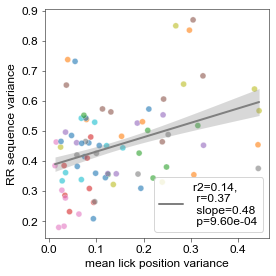

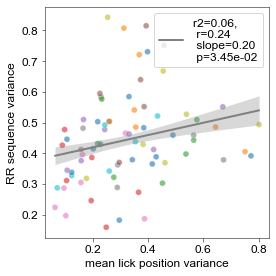

In [10]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(ax=ax,data=seq_shape_df, x='lickvar0', y='seqvar0', hue='an', palette='tab10', alpha=0.6, legend=False)
pt.plot_lin_reg(seq_shape_df['lickvar0'], seq_shape_df['seqvar0'], ax=ax)
ax.set_xlabel('mean lick position variance')
ax.set_ylabel('RR sequence variance')

fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(ax=ax,data=seq_shape_df, x='lickvar1', y='seqvar1', hue='an', palette='tab10', alpha=0.6, legend=False)
pt.plot_lin_reg(seq_shape_df['lickvar1'], seq_shape_df['seqvar1'], ax=ax)
ax.set_xlabel('mean lick position variance')
ax.set_ylabel('RR sequence variance')

In [92]:
seq_shape_df['env'] = np.zeros((len(seq_shape_df),))
seq_shape_df.loc[seq_shape_df['day'].isin([3,5,7,10,12,14]),'env'] = 'fam'
seq_shape_df.loc[seq_shape_df['day'].isin([8]),'env'] = 'novel'
seq_shape_df['switch'] = seq_shape_df['switch']+1

In [ ]:
# ut.write_source_csv(seq_shape_df, "3pED4h-j")

In [ ]:
## If you're curious, the relationship with rr sequence variance is also significant with the anticipatory lick ratio
fig, ax = plt.subplots(1,2,figsize=(8,4))
sns.scatterplot(data=seq_shape_df, x='lickratio0', y='seqvar0', hue='an', palette = 'tab10',ax=ax[0], alpha=0.7)
sns.scatterplot(data=seq_shape_df, x='lickratio1', y='seqvar1', hue='an', palette = 'tab10', ax=ax[1], alpha=0.7)
pt.plot_lin_reg(seq_shape_df['lickratio0'], seq_shape_df['seqvar0'], ax=ax[0])
pt.plot_lin_reg(seq_shape_df['lickratio1'], seq_shape_df['seqvar1'], ax=ax[1])


[ax[i].set_xlim([-0.2,1.05]) for i in range(ax.shape[0])]
[ax[i].set_ylim([0,0.95]) for i in range(ax.shape[0])]


save_figures=False
if save_figures:
    figname = "%s_expday%s_LickRatio-vs-SeqVar_LinReg_hue-by-day_%s_%s_%s_%s_%s_allAn" % (
            ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days), celltype, ts_key, circ_tag, place_cell_logical, anchor_tag)
    pt.savefig(fig, fig_dir, figname)

#### Ext. Fig 4 LMMs

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/

left column = before switch; right column = after switch


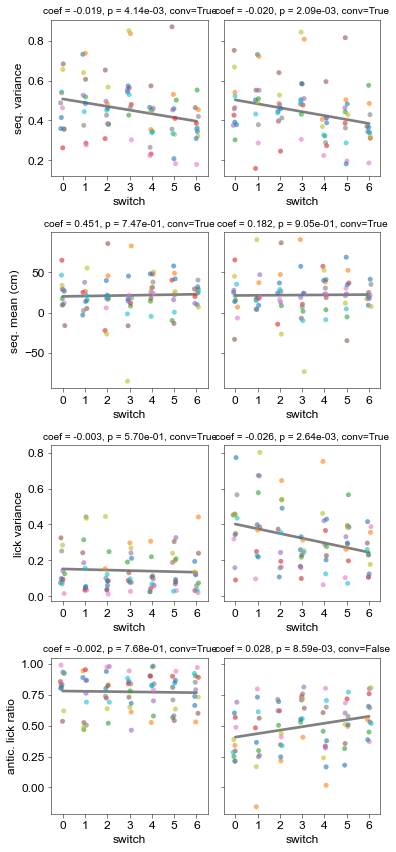

In [12]:
fig, ax = plt.subplots(4,2,figsize=(5.5,12), sharey='row')

pt.lmm_plot('switch','seqvar0',seq_shape_df,subject='an',ax=ax[0,0], markers='', logit_expit=False)
pt.lmm_plot('switch','seqvar1',seq_shape_df,subject='an',ax=ax[0,1], markers='', logit_expit=False)

pt.lmm_plot('switch','seqmean0_cm',seq_shape_df,subject='an',ax=ax[1,0], markers='')
pt.lmm_plot('switch','seqmean1_cm',seq_shape_df,subject='an',ax=ax[1,1], markers='')

pt.lmm_plot('switch','lickvar0',seq_shape_df,subject='an',ax=ax[2,0], markers='', logit_expit=False)
pt.lmm_plot('switch','lickvar1',seq_shape_df,subject='an',ax=ax[2,1], markers='', logit_expit=False)

pt.lmm_plot('switch', 'lickratio0', data_df=seq_shape_df, subject='an', ax=ax[3,0],markers='')
pt.lmm_plot('switch', 'lickratio1', data_df=seq_shape_df, subject='an', ax=ax[3,1],markers='')


ax[0,0].set_ylabel('seq. variance')
ax[1,0].set_ylabel('seq. mean (cm)')
ax[2,0].set_ylabel('lick variance')
ax[3,0].set_ylabel('antic. lick ratio')

save_figures=False
if save_figures:
    figname = "%s_expday%s_Day-vs-SeqVar-SeqMean_LMM_%s_%s_%s_%s_%s_allAn" % (
            ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days), celltype, ts_key, circ_tag, place_cell_logical, anchor_tag)
    pt.savefig(fig, fig_dir, figname)
    
print('left column = before switch; right column = after switch')

In [13]:
## To-do - pick joint examples
seq_shape_df.sort_values(by=['seqvar0','lickvar0'], ascending=True)

,an,day,switch,switch_dir,seqvar0,seqvar1,lickvar0,lickvar1,lickratio0,lickratio1,seqmean0,seqmean1,seqmean0_cm,seqmean1_cm
72,GCAMP14,14,6,forward,0.179125,0.186366,0.020638,0.387782,0.972004,0.370284,0.362423,0.308403,25.956615,22.087746
61,GCAMP14,12,5,backward,0.182995,0.196687,0.031887,0.103257,0.940819,0.684097,0.326663,0.425520,23.395537,30.475648
65,GCAMP19,12,5,forward,0.207865,0.182066,0.093871,0.296472,0.847795,0.507763,0.587173,0.486335,42.053160,34.831165
50,GCAMP14,10,4,backward,0.223446,0.223661,0.063300,0.064221,0.790079,0.803368,0.334386,0.326622,23.948633,23.392584
47,GCAMP11,10,4,backward,0.231453,0.272906,0.043408,0.366376,0.901150,0.335214,0.671971,0.806132,48.126343,57.734953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,GCAMP3,5,1,forward,0.731662,0.730602,0.055190,0.398522,0.890225,0.364546,-0.040090,0.060830,-2.871206,4.356640
12,GCAMP4,5,1,forward,0.737509,0.721118,0.039667,0.368688,0.945047,-0.157030,0.372315,0.520847,26.665071,37.302908
34,GCAMP4,8,3,forward,0.835506,0.807509,0.296981,0.313230,0.610451,0.406238,1.158998,1.269306,83.007091,90.907348
41,GCAMP17,8,3,backward,0.850081,0.843104,0.268157,0.254472,0.648837,0.717520,-1.188769,-1.022724,-85.139283,-73.247217


#### Plot the examples in Ext Fig. 4f-g

Here just for "before", feel free to change it

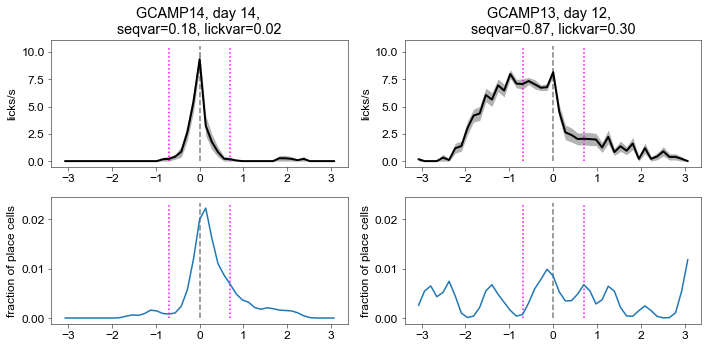

In [19]:
# Pick a low and high sequence variance example from the dataframe above

fig, ax = plt.subplots(2,2,figsize=(10,5))

narrow_an = 'GCAMP14'
broad_an = 'GCAMP13'
narrow_day = 14
broad_day = 12

pt.plot_mean_sem(ax[0,0], 
                 np.nanmean(multiDayData[narrow_day].circ_licks[narrow_an]['set 0'],axis=0),
                 ut.sem(multiDayData[narrow_day].circ_licks[narrow_an]['set 0'],axis=0),
                xvalues=lick_bin_centers)

pt.plot_mean_sem(ax[0,1], 
                 np.nanmean(multiDayData[broad_day].circ_licks[broad_an]['set 0'],axis=0),
                 ut.sem(multiDayData[broad_day].circ_licks[broad_an]['set 0'],axis=0),
                 xvalues=lick_bin_centers)

narrow_hist = np.histogram(seq_pos0[narrow_day][narrow_an], #mean_seq_pos[narrow_day][narrow_an], 
                                                       bins=bin_edges)[0] / np.sum(
            multiDayData[narrow_day].overall_place_cell_masks[narrow_an])
narrow_hist = ut.nansmooth(best_hist,1)

ax[1,0].plot(bin_centers, best_hist)

broad_hist = np.histogram(seq_pos0[broad_day][broad_an], #mean_seq_pos[broad_day][broad_an], 
                                                       bins=bin_edges)[0] / np.sum(
            multiDayData[broad_day].overall_place_cell_masks[broad_an])
broad_hist = ut.nansmooth(broad_hist,1)

ax[1,1].plot(bin_centers, broad_hist)

ylim = ax[0,0].get_ylim()[-1]
for col in  [0,1]:
    ax[0,col].vlines(0,0, ylim,linestyle='--',color='grey')
    ax[0,col].vlines(-multiDayData[narrow_day].circ_rel_stats_across_an['rdist_to_rad_exc'],0, ylim,linestyle=':',color='magenta')
    ax[0,col].vlines(multiDayData[narrow_day].circ_rel_stats_across_an['rdist_to_rad_exc'],0, ylim,linestyle=':',color='magenta')
    ax[0,col].set_ylabel('licks/s')
    
ylim = ax[1,0].get_ylim()[-1]
for col in  [0,1]:
    ax[1,col].vlines(0,0, ylim,linestyle='--',color='grey')
    ax[1,col].vlines(-multiDayData[narrow_day].circ_rel_stats_across_an['rdist_to_rad_exc'],0, ylim,linestyle=':',color='magenta')
    ax[1,col].vlines(multiDayData[narrow_day].circ_rel_stats_across_an['rdist_to_rad_exc'],0, ylim,linestyle=':',color='magenta')
    ax[1,col].set_ylabel('fraction of place cells')

ax[0,0].set_title("%s, day %d, \nseqvar=%.2f, lickvar=%.2f" % (narrow_an, narrow_day,
                                                                 seq_shape_df.loc[(seq_shape_df['an']==narrow_an) 
                                                                                  & (seq_shape_df['day']==narrow_day)]['seqvar0'],
                                                                 seq_shape_df.loc[(seq_shape_df['an']==narrow_an) 
                                                                                  & (seq_shape_df['day']==narrow_day)]['lickvar0'],   
                                                               ))
                                                                                 
ax[0,1].set_title("%s, day %d,  \nseqvar=%.2f, lickvar=%.2f" % (broad_an, broad_day,
                                                                   seq_shape_df.loc[(seq_shape_df['an']==broad_an) 
                                                                                  & (seq_shape_df['day']==broad_day)]['seqvar0'],
                                                                 seq_shape_df.loc[(seq_shape_df['an']==broad_an) 
                                                                                  & (seq_shape_df['day']==broad_day)]['lickvar0'],  
                                                                ))
                 
save_figures = False
if save_figures:
    if anchor_to_reward:
        anchor_tag = 'rranchor'
    else:
        anchor_tag = 'linanchor'
    pt.savefig(fig, fig_dir, "%s-%s_expday%d-%d_CircLicks0-vs-Seq0_%s_%s_%s_%s_%s" % (
        narrow_an,broad_an,narrow_day,broad_day, celltype, ts_key, circ_tag, place_cell_logical, anchor_tag)
           )

## Quantify fractions near and far from the reward zone start from the rainbow plots (Fig. 4m-o, r)

In [32]:
# columns=['mouse','day','switch','frac_rr_around_rew'])
df_seq_frac = pd.DataFrame()

near_rew_bins = np.array([-multiDayData[exp_days[0]].circ_rel_stats_across_an['rdist_to_rad_exc'],
                          multiDayData[exp_days[0]
                                       ].circ_rel_stats_across_an['rdist_to_rad_exc']
                          ])

near_end_edges = np.array([-np.pi+multiDayData[exp_days[0]].circ_rel_stats_across_an['rdist_to_rad_exc'],
                           np.pi -
                           multiDayData[exp_days[0]
                                        ].circ_rel_stats_across_an['rdist_to_rad_exc']
                           ])

speed_bin_centers = multiDayData[exp_days[0]].circ_speed[an]['set 1'][-1]

for d_i, d in enumerate(exp_days):
    for an_i, an in enumerate(seq[d].keys()):

        n_place_cells = np.sum(multiDayData[d].overall_place_cell_masks[an])
        n_all_cells = len(multiDayData[d].overall_place_cell_masks[an])

        rr_cells = multiDayData[d].reward_rel_cell_ids[an]

        near_reward, _ = np.histogram(
            mean_seq_pos[d][an], bins=near_rew_bins)

        # fraction out of place cells:
        near_reward_norm_to_pcs = near_reward / n_place_cells

        # rr cells not near reward:
        far_reward = (len(mean_seq_pos[d][an]) - near_reward)
        far_reward_norm_to_pcs = far_reward / n_place_cells

        # cells near track ends (assuming this category is track-relative cells)
        near_ends = np.sum(np.logical_or(
            mean_seq_pos[d][an] < near_end_edges[0],
            mean_seq_pos[d][an] > near_end_edges[1]
        ))
        # cells far from track ends
        far_ends = len(mean_seq_pos[d][an]) - near_ends
        near_ends_norm_to_pcs = near_ends / n_place_cells
        far_ends_norm_to_pcs = far_ends / n_place_cells

        lick_bins_near_reward = np.logical_and(lick_bin_centers > near_rew_bins[0],
                                               lick_bin_centers < near_rew_bins[1])
        speed_bins_near_reward = np.logical_and(speed_bin_centers > near_rew_bins[0],
                                                speed_bin_centers < near_rew_bins[1])

        # average across trials
        this_speed = np.nanmean(
            multiDayData[d].circ_speed[an]['set 1'][0], axis=0)
        this_licks = np.nanmean(
            multiDayData[d].circ_licks[an]['set 1'], axis=0)

        mean_lick_near_reward = np.nanmean(
            this_licks[lick_bins_near_reward])
        mean_speed_near_reward = np.nanmean(
            this_speed[speed_bins_near_reward])
        mean_lick_away_reward = np.nanmean(
            this_licks[~lick_bins_near_reward])
        mean_speed_away_reward = np.nanmean(
            this_speed[~speed_bins_near_reward])

        df_seq_frac = df_seq_frac.append({'mouse': an,
                                          'day': d,
                                          'switch': d_i+1,                                      
                                          'frac_near_reward_of_pcs': near_reward_norm_to_pcs[0],
                                          'frac_near_reward_of_pcs_logit': sp.special.logit(ut.avoid_naninf(near_reward_norm_to_pcs))[0],
                                          'frac_far_reward_of_pcs': far_reward_norm_to_pcs[0],
                                          'frac_far_reward_of_pcs_logit': sp.special.logit(ut.avoid_naninf(far_reward_norm_to_pcs))[0],
                                          'frac_near_ends_of_pcs': near_ends_norm_to_pcs,
                                          'frac_far_ends_of_pcs': far_ends_norm_to_pcs,
                                          'frac_near_ends_of_pcs_logit': sp.special.logit(ut.avoid_naninf(near_ends_norm_to_pcs)),
                                          'frac_far_ends_of_pcs_logit': sp.special.logit(ut.avoid_naninf(far_ends_norm_to_pcs)),
                                          'lick_near_reward': mean_lick_near_reward,
                                          'lick_far_reward': mean_lick_away_reward,
                                          'speed_near_reward': mean_speed_near_reward,
                                          'speed_far_reward': mean_speed_away_reward,
                                          }, ignore_index=True)

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/base/model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packag

--- celltype: rr


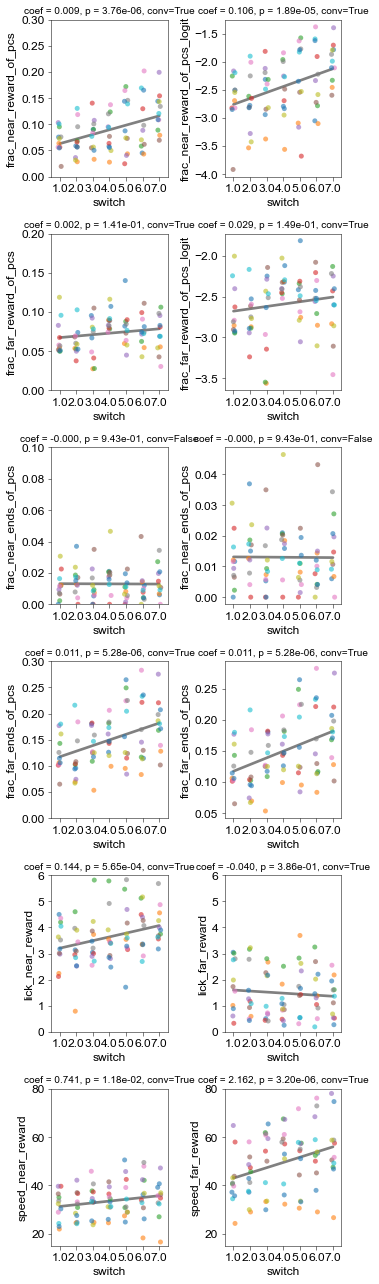

In [33]:
fig, ax = plt.subplots(6, 2, figsize=(5, 18))

keys = ['near_reward_of_pcs','far_reward_of_pcs']
palette = "tab10"
logit_expit = False

for k_i, key in enumerate(keys):
    pt.lmm_plot('switch', f'frac_{key}', df_seq_frac, ax=ax[k_i, 0], legend_on=False, palette=palette,
                logit_expit=logit_expit, markers='')
    pt.lmm_plot('switch', f'frac_{key}_logit', df_seq_frac,
                ax=ax[k_i, 1], legend_on=False, palette=palette)

pt.lmm_plot('switch', 'frac_near_ends_of_pcs', df_seq_frac,
            ax=ax[2, 0], legend_on=False, palette=palette)
pt.lmm_plot('switch', 'frac_far_ends_of_pcs', df_seq_frac,
            ax=ax[3, 0], legend_on=False, palette=palette)
pt.lmm_plot('switch', 'frac_near_ends_of_pcs', df_seq_frac, ax=ax[2, 1], legend_on=False, palette=palette,
            logit_expit=logit_expit)

pt.lmm_plot('switch', 'frac_far_ends_of_pcs', df_seq_frac, ax=ax[3, 1], legend_on=False, palette=palette,
            logit_expit=logit_expit)

# behavior

pt.lmm_plot('switch', 'lick_near_reward', df_seq_frac,
            ax=ax[4, 0], legend_on=False, palette=palette)
pt.lmm_plot('switch', 'lick_far_reward', df_seq_frac,
            ax=ax[4, 1], legend_on=False, palette=palette)
pt.lmm_plot('switch', 'speed_near_reward', df_seq_frac,
            ax=ax[5, 0], legend_on=False, palette=palette)
pt.lmm_plot('switch', 'speed_far_reward', df_seq_frac,
            ax=ax[5, 1], legend_on=False, palette=palette)

[ax[j, 0].set_ylim([0, ut.round_up(ax[j, 0].get_ylim()[-1], decimals=1)])
 for j in [0, 1, 2, 3]]
[ax[-2, j].set_ylim([0, 6]) for j in [0, 1]]
[ax[-1, j].set_ylim([15, 80]) for j in [0, 1]]

print('--- celltype:', celltype)

save_figure = False
if save_figure:
    if anchor_to_reward:
        anchor_tag = 'rranchor'
    else:
        anchor_tag = 'linanchor'
    pt.savefig(fig, fig_dir, (
        "%s_%s_fracHist_near_reward_%s_%s_ofPlaceCells-%sOnly-wBehavior_postswitch_%s" % (
            ut.make_anim_tag(include_ans),
            ut.make_day_tag(exp_days),
            circ_tag,
            place_cell_logical,
            celltype,
            anchor_tag))
    )

In [ ]:
df_seq_frac

In [27]:
# ut.write_source_csv(df_seq_frac, "Ext4l")

writing /data/2P/source_data/FigExt4l.csv


# Now go back to the sequence shape calculation to enter another cell type

[Go to sequence shape calculation](#Start-here-for-Fig-4j-onward)